# **Практическая работа №4. Метод K-ближайших соседей**

Для всех классификаторов из Sklearn подбирайте лучшие гиперпараметры для модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

# **Базовый алгоритм KNN**

## **KNN для классификации**

### **Получение данных**

Будем работать с набором данным `iris` из `sklearn`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, r2_score

data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=10, test_size=30
)

X_train.shape, X_test.shape

((120, 4), (30, 4))

#### 1.2. Обучите модель KNN

In [4]:
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 3
model = KNeighborsClassifier(n_neighbors=n_neighbors)

model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


#### 1.3. Проверьте качество работы модели

In [5]:
pred_test = model.predict(X_test)
pred_test

array([1, 2, 0, 1, 0, 1, 2, 1, 0, 1, 1, 2, 1, 0, 0, 2, 1, 0, 0, 0, 2, 2,
       2, 0, 1, 0, 1, 1, 1, 2])

#### 1.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

In [6]:
from sklearn.metrics import accuracy_score

neighbors = [1, 3, 5, 7, 9, 11, 15, 20]
scores = []

for n in neighbors:
    model = KNeighborsClassifier(n_neighbors=n)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

pd.DataFrame({'n_neighbors': neighbors, 'score': scores})

,n_neighbors,score
0,1,0.966667
1,3,0.966667
2,5,0.966667
3,7,0.966667
4,9,1.000000
5,11,1.000000
6,15,1.000000
7,20,1.000000


### **2. KNN рукописный**

#### 2.1. Возьмите два случайных тестовых объектов

In [7]:
idx = [0, 1]
test_dots = X_test.iloc[idx].values
test_dots


array([[6.3, 2.3, 4.4, 1.3],
       [6.4, 2.7, 5.3, 1.9]])

#### 2.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [8]:
distances = []

for test_dot in test_dots:
    distances_data = []

    for i, train_dot in enumerate(X_train.values):
        distances_data.append({
            'train_idx': i,
            'dst': np.linalg.norm(train_dot - test_dot, ord=2)
        })

    distances.append(pd.DataFrame(distances_data))

distances[0].sort_values('dst').head(3), distances[1].sort_values('dst').head(3)


(     train_idx       dst
 20          20  0.264575
 101        101  0.591608
 105        105  0.608276,
     train_idx       dst
 69         69  0.346410
 51         51  0.374166
 4           4  0.374166)

#### 2.3. Выберите топ $k$ соседей для каждого объекта

In [9]:
n_neighbors = 3

neighbors = []
for distance in distances:
    neighbors.append(distance.sort_values('dst').head(n_neighbors))

neighbors


[     train_idx       dst
 20          20  0.264575
 101        101  0.591608
 105        105  0.608276,
     train_idx       dst
 69         69  0.346410
 51         51  0.374166
 4           4  0.374166]

#### 2.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [10]:
predictions = []

for neighbors_data in neighbors:
    idxs = neighbors_data['train_idx'].values
    labels = y_train[idxs]
    predictions.append(pd.Series(labels).mode()[0])

predictions


[np.int64(1), np.int64(2)]

#### 2.5. Сравните с настоящими целевыми значениями этих двух объектов

In [11]:
y_test[idx], predictions


(array([1, 2]), [np.int64(1), np.int64(2)])

## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [12]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### **KNN из sklearn**

#### 3.1. Разбейте данные на обучение и тест

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=10, test_size=20
)

X_train.shape, X_test.shape

((20620, 8), (20, 8))

Затем нормализуйте данные:

In [14]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
mms.fit(X_train)

X_train = pd.DataFrame(mms.transform(X_train[X_train.columns]), columns=X_train.columns)
X_test = pd.DataFrame(mms.transform(X_test[X_train.columns]), columns=X_train.columns)

#### 3.2. Обучите модель KNN


In [15]:
from sklearn.neighbors import KNeighborsRegressor

n_neighbors = 3
model = KNeighborsRegressor(n_neighbors=n_neighbors)

model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


#### 3.3. Проверьте качество работы модели

In [16]:
pred_test = model.predict(X_test)
r2_score(y_test, pred_test)

0.3124891961652865

#### 3.4. Поэкспериментируйте с количеством соседей

1. Обучите модели с разным кол-вом соседей
2. Посчитайте метрику на тестовой выборке
3. Соберите данные в таблицу/график для наглядности
4. Выберите самое оптимальное значение $k$

In [17]:
neighbors = [1, 3, 5, 7, 9, 11, 15, 20]
scores = []

for n in neighbors:
    model = KNeighborsRegressor(n_neighbors=n)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(r2_score(y_test, pred))

pd.DataFrame({'n_neighbors': neighbors, 'score': scores})


,n_neighbors,score
0,1,0.482297
1,3,0.312489
2,5,0.448562
3,7,0.601444
4,9,0.534015
5,11,0.541989
6,15,0.539364
7,20,0.582176


### **4. KNN рукописный**

#### 4.1. Возьмите два случайных тестовых объектов

In [18]:
idx = [0, 1]
test_dots = X_test.iloc[idx].values
test_dots


array([[0.32954028, 0.21568627, 0.02566135, 0.01918723, 0.01126713,
        0.00260713, 0.17215728, 0.51494024],
       [0.23946566, 0.50980392, 0.02674776, 0.02261929, 0.05252389,
        0.00121784, 0.53241233, 0.20318725]])

#### 4.2. Посчитайте для каждого расстояния до всех объектов из обучения

In [19]:
distances = []

for test_dot in test_dots:
    distances_data = []

    for i, train_dot in enumerate(X_train.values):
        distances_data.append({
            'train_idx': i,
            'dst': np.linalg.norm(train_dot - test_dot, ord=2)
        })

    distances.append(pd.DataFrame(distances_data))

distances[0].sort_values('dst').head(3), distances[1].sort_values('dst').head(3)


(       train_idx       dst
 2937        2937  0.029117
 16342      16342  0.063238
 19405      19405  0.065230,
        train_idx       dst
 19369      19369  0.019080
 2784        2784  0.020674
 4758        4758  0.028331)

#### 4.3. Выберите топ $k$ соседей для каждого объекта

In [20]:
n_neighbors = 3

neighbors = []
for distance in distances:
    neighbors.append(distance.sort_values('dst').head(n_neighbors))

neighbors


[       train_idx       dst
 2937        2937  0.029117
 16342      16342  0.063238
 19405      19405  0.065230,
        train_idx       dst
 19369      19369  0.019080
 2784        2784  0.020674
 4758        4758  0.028331]

#### 4.4. Выведите финальное предсказание для двух объектов основываясь на соседях

In [21]:
predictions = []

for neighbors_data in neighbors:
    idxs = neighbors_data['train_idx'].values
    predictions.append(np.mean(y_train[idxs]))

predictions


[np.float64(3.026), np.float64(3.135333333333333)]

#### 4.5. Сравните с настоящими целевыми значениями этих двух объектов

In [22]:
y_test[idx], predictions


(array([1.674, 3.541]), [np.float64(3.026), np.float64(3.135333333333333)])

Предсказания отклоняются от истины, но не так сильно, они довольно близки.

# **Weighted KNN**

## **KNN для классификации**

### Получение данных

Будем работать с набором данным `iris` из `sklearn`.

In [23]:
from sklearn.datasets import load_iris
import pandas as pd


data = load_iris()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [24]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Выберите только 0 и 3 признак (sepal length (cm) и petal width (cm))

In [25]:
X = X.iloc[:, [0, 3]]
X.head()

,sepal length (cm),petal width (cm)
0,5.1,0.2
1,4.9,0.2
2,4.7,0.2
3,4.6,0.2
4,5.0,0.2


### Визуализируйте ваши данные на графике

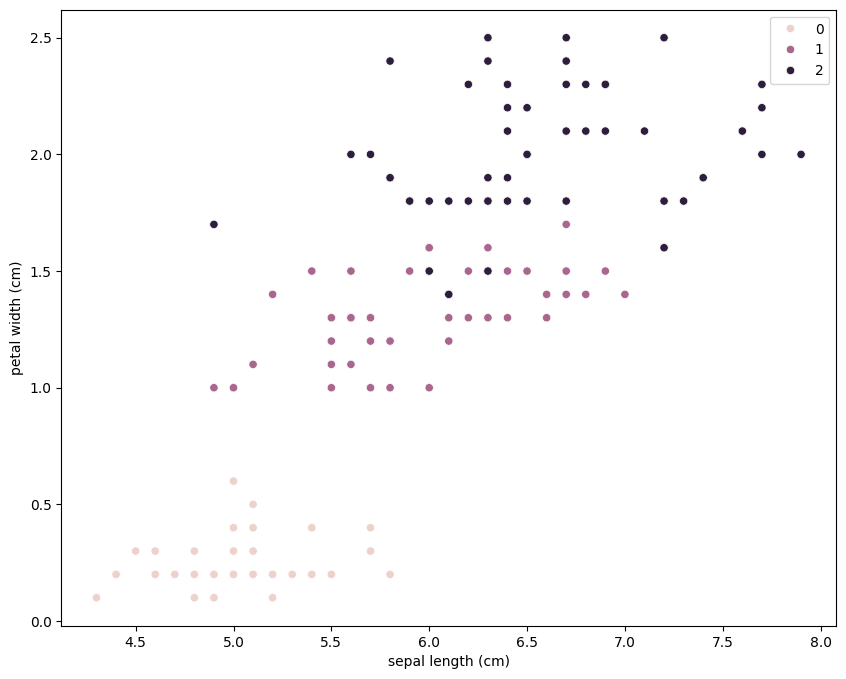

In [26]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=X.iloc[:, 0],
    y=X.iloc[:, 1],
    hue=y
)

plt.legend()

### **1. KNN из sklearn**

#### 1.1. Разбейте данные на обучение и тест

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=6, test_size=5
)

X_train.shape, X_test.shape

((145, 2), (5, 2))

#### 1.2. Обучите модель KNN на 50 соседях

In [28]:
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 50
model = KNeighborsClassifier(n_neighbors=n_neighbors)

model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


#### 1.3. Проверьте качество работы модели

In [29]:
pred_test = model.predict(X_test)
accuracy_score(y_test, pred_test)

1.0

#### 1.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [30]:
idx = 0
test_dot = X_test.iloc[idx].values

distances_data = []

for i, train_dot in enumerate(X_train.values):
    distances_data.append({
        'train_idx': i,
        'dst': np.linalg.norm(train_dot - test_dot, ord=2)
    })

distances = pd.DataFrame(distances_data)
distances


,train_idx,dst
0,0,1.303840
1,1,1.627882
2,2,0.100000
3,3,2.126029
4,4,1.208305
...,...,...
140,140,2.418677
141,141,1.063015
142,142,3.182766
143,143,1.503330


#### 1.5. Выберите топ  k  соседей


In [31]:
nearest_neigbors_idxs = distances.sort_values('dst').head(n_neighbors).index
nearest_neigbors_idxs

Index([ 34,  90,  97, 137,  43,  18,  39,   2, 136, 109, 118,  35,  15,  76,
       133,  42, 116,  94, 100,  23,  79,  17,  25,  14,  40,  64,  93, 115,
        52,  80,  96, 103,  61,  48, 113,  27, 128,  86,  89,  95,  92,  51,
       130,  28,  50, 126,  63,  56,  24, 114],
      dtype='int64')

#### 1.6. Выведите финальное предсказание для этого объекта

In [32]:
labels = y_train[nearest_neigbors_idxs]
pred = pd.Series(labels).mode()[0]
pred

np.int64(0)

#### 1.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [33]:
y_test[idx], pred, model.predict(X_test.iloc[[idx]])[0]


(np.int64(0), np.int64(0), np.int64(0))

In [34]:
model.predict(X_test.iloc[[idx]])[0]

np.int64(0)

#### 1.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

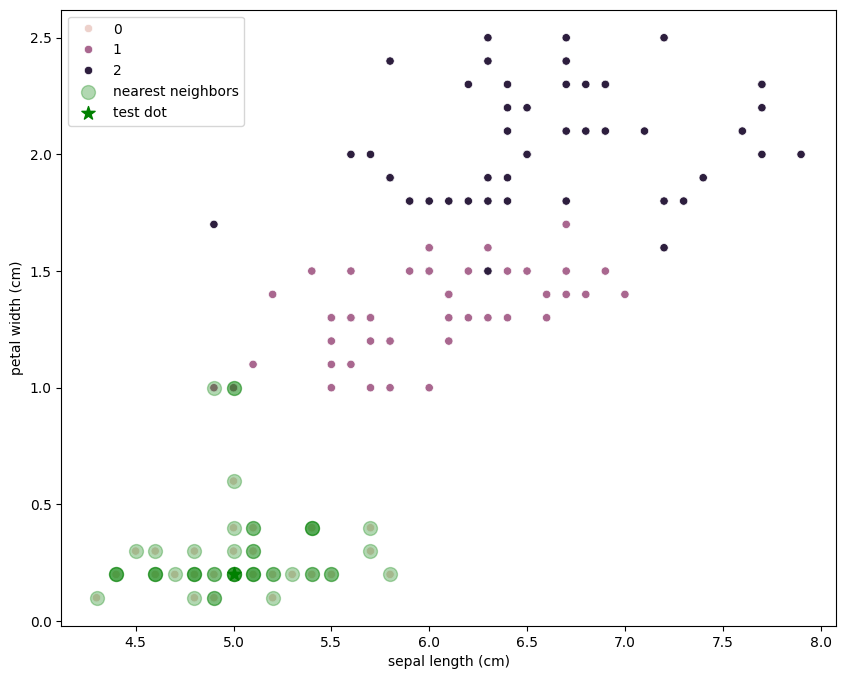

In [35]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=X_train.iloc[:, 0],
    y=X_train.iloc[:, 1],
    hue=y_train
)

plt.scatter(
    X_train.iloc[nearest_neigbors_idxs, 0],
    X_train.iloc[nearest_neigbors_idxs, 1],
    c='g',
    alpha=0.3,
    marker='o',
    s=100,
    label='nearest neighbors'
)

plt.scatter(
    X_test.iloc[idx, 0],
    X_test.iloc[idx, 1],
    c='g',
    marker='*',
    s=100,
    label='test dot'
)

plt.legend()

### **2. Weighted KNN**

#### 2.1. Обучите модель "взвешенный KNN" по дистанции

In [36]:
n_neighbors = 50
model = KNeighborsClassifier(n_neighbors=n_neighbors, weights='distance')

model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


#### 2.2. Проверьте качество работы модели


In [37]:
pred_test = model.predict(X_test)
accuracy_score(y_test, pred_test)

1.0

#### 2.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [38]:
idx = 0
test_dot = X_test.iloc[idx].values

distances_data = []

for i, train_dot in enumerate(X_train.values):
    distances_data.append({
        'train_idx': i,
        'dst': np.linalg.norm(train_dot - test_dot, ord=2)
    })

distances = pd.DataFrame(distances_data)
distances


,train_idx,dst
0,0,1.303840
1,1,1.627882
2,2,0.100000
3,3,2.126029
4,4,1.208305
...,...,...
140,140,2.418677
141,141,1.063015
142,142,3.182766
143,143,1.503330


#### 2.4. Выберите топ  k  соседей


In [39]:
nearest_neigbors_idxs = distances.sort_values('dst').head(n_neighbors).index
nearest_neigbors_idxs

Index([ 34,  90,  97, 137,  43,  18,  39,   2, 136, 109, 118,  35,  15,  76,
       133,  42, 116,  94, 100,  23,  79,  17,  25,  14,  40,  64,  93, 115,
        52,  80,  96, 103,  61,  48, 113,  27, 128,  86,  89,  95,  92,  51,
       130,  28,  50, 126,  63,  56,  24, 114],
      dtype='int64')

#### 2.5. Рассчитайте вес для каждого соседа

In [40]:
distances['weight'] = 1 / distances['dst']
distances = distances.sort_values('dst').head(n_neighbors)
distances

,train_idx,dst,weight
34,34,0.000000,inf
90,90,0.000000,inf
97,97,0.000000,inf
137,137,0.000000,inf
43,43,0.100000,10.000000
18,18,0.100000,10.000000
39,39,0.100000,10.000000
2,2,0.100000,10.000000
136,136,0.100000,10.000000
109,109,0.100000,10.000000


#### 2.6. Выведите финальное предсказание для этого объекта

In [41]:
labels = y_train[distances['train_idx'].values]
weights = distances['weight'].values

weight_data = pd.DataFrame({'label': labels, 'weight': weights})
pred = weight_data.groupby('label')['weight'].sum().idxmax()
pred

np.int64(0)

#### 2.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [42]:
y_test[idx], pred, model.predict(X_test.iloc[[idx]])[0]


(np.int64(0), np.int64(0), np.int64(0))

In [43]:
model.predict(X_test.iloc[[idx]])[0]

np.int64(0)

#### 2.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

In [44]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=X_train.iloc[:, 0],
    y=X_train.iloc[:, 1],
    hue=y_train
)

plt.scatter(
    X_train.iloc[nearest_neigbors_idxs, 0],
    X_train.iloc[nearest_neigbors_idxs, 1],
    c='g',
    alpha=0.3,
    marker='o',
    s=distances['weight'] * 1000,
    label='nearest neighbors'
)

plt.scatter(
    X_test.iloc[idx, 0],
    X_test.iloc[idx, 1],
    c='g',
    marker='*',
    s=100,
    label='test dot'
)

plt.legend()

Error in callback <function _draw_all_if_interactive at 0x0000010AD7E55440> (for post_execute), with arguments args (),kwargs {}:


ValueError: need at least one array to concatenate

ValueError: need at least one array to concatenate

<Figure size 1000x800 with 1 Axes>

## **KNN для регрессии**

### Получение данных


Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [45]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [46]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

### Возьмите только признак MedInc и 1000 первых строк

In [47]:
X = X[['MedInc']].head(1000)
y = y[:1000]

X.head()

,MedInc
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462


### Отрисуйте данные на графике

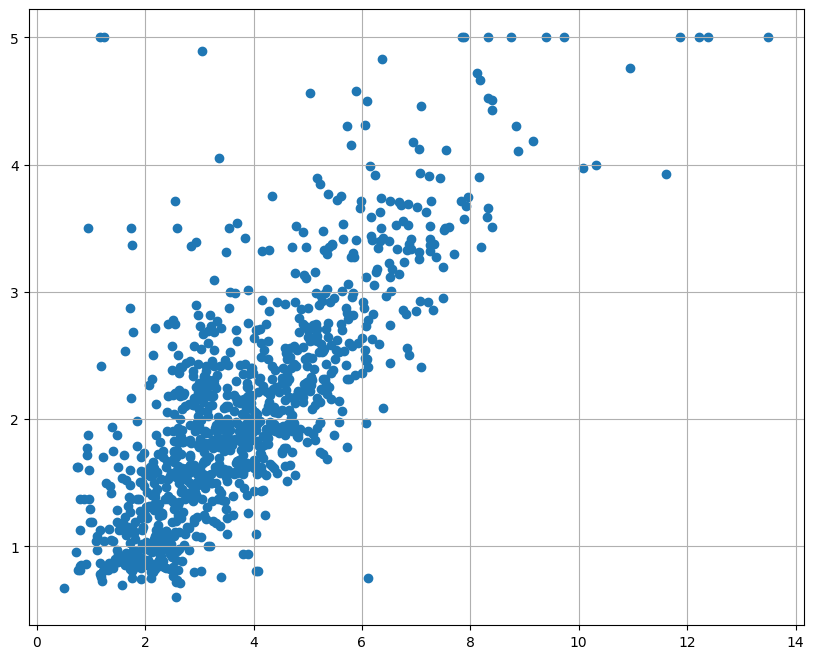

In [48]:
plt.figure(figsize=(10, 8))
plt.scatter(X, y)
plt.grid()

### **4. KNN из sklearn**

#### 4.1. Разбейте данные на обучение и тест

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=12, test_size=5
)

X_train.shape, X_test.shape

((995, 1), (5, 1))

#### 4.2. Обучите модель KNN на 100 соседях


In [50]:
from sklearn.neighbors import KNeighborsRegressor

n_neighbors = 100
model = KNeighborsRegressor(n_neighbors=n_neighbors)

model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",100
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


#### 4.3. Проверьте качество работы модели


In [51]:
pred_test = model.predict(X_test)
r2_score(y_test, pred_test)

0.7053073615236285

#### 4.4. Возьмите один случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [52]:
idx = 0
test_dot = X_test.iloc[idx].values

distances_data = []

for i, train_dot in enumerate(X_train.values):
    distances_data.append({
        'train_idx': i,
        'dst': np.linalg.norm(train_dot - test_dot, ord=2)
    })

distances = pd.DataFrame(distances_data)
distances


,train_idx,dst
0,0,1.4531
1,1,3.1061
2,2,3.5030
3,3,1.2086
4,4,3.2300
...,...,...
990,990,4.3078
991,991,3.4785
992,992,3.3514
993,993,2.4925


#### 4.5. Выберите топ  k  соседей


In [53]:
nearest_neigbors_idxs = distances.sort_values('dst').head(n_neighbors).index
nearest_neigbors_idxs

Index([978, 233, 269, 887, 320, 250, 272, 181, 327, 725, 386, 186, 427, 841,
       112, 736, 544, 759, 187, 750, 657, 224, 641,  44, 808, 483, 987, 248,
       526, 551,  17, 316, 179, 217, 810, 964, 781, 500,  88, 540, 513, 682,
       264, 714, 840, 130, 568, 917, 189, 765, 986,  23, 543, 366, 958, 883,
       801, 678, 455, 667, 404, 331, 430, 982, 822, 537, 539, 498, 100, 909,
         9, 267, 668, 261, 643, 645, 850, 218, 319, 175, 626, 557, 806, 279,
       287, 889, 796, 148, 994, 797, 553, 776, 753, 374, 571, 789, 516,  11,
       915, 594],
      dtype='int64')

#### 4.6. Выведите финальное предсказание для этого объекта

In [54]:
pred = np.mean(y_train[nearest_neigbors_idxs])
pred

np.float64(3.0131900000000007)

#### 4.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [55]:
y_test[idx], pred, model.predict(X_test.iloc[[idx]])[0]


(np.float64(3.986),
 np.float64(3.0131900000000007),
 np.float64(3.0131900000000007))

In [56]:
model.predict(X_test.iloc[[idx]])[0]

np.float64(3.0131900000000007)

#### 4.8 Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей

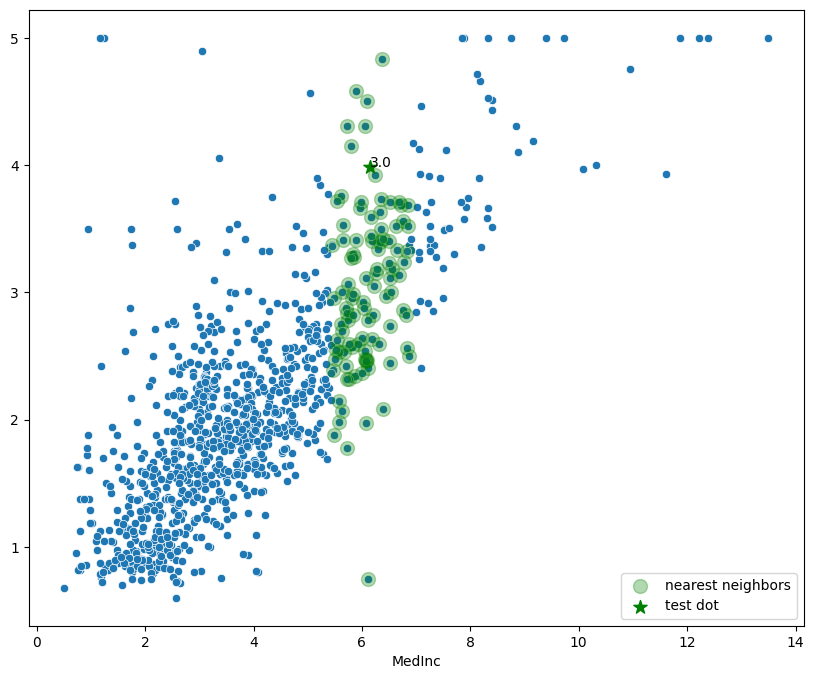

In [57]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=X_train.iloc[:, 0],
    y=y_train
)

plt.scatter(
    X_train.iloc[nearest_neigbors_idxs, 0],
    y_train[nearest_neigbors_idxs],
    c='g',
    alpha=0.3,
    marker='o',
    s=100,
    label='nearest neighbors'
)

plt.scatter(
    X_test.iloc[idx, 0],
    y_test[idx],
    c='g',
    marker='*',
    s=100,
    label='test dot'
)

plt.annotate(round(pred, 1), (X_test.iloc[idx, 0], y_test[idx]))
plt.legend()

### **5. Weighted KNN**

#### 5.1. Обучите модель взвешенный KNN по дистанции

In [58]:
n_neighbors = 100
model = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')

model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",100
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


#### 5.2. Проверьте качество работы модели


In [59]:
pred_test = model.predict(X_test)
r2_score(y_test, pred_test)


0.49366711447302447

#### 5.3. Возьмите тот же случайный тестовый объект и посчитайте для него расстояния до всех объектов с обучения

In [60]:
idx = 0
test_dot = X_test.iloc[idx].values

distances_data = []

for i, train_dot in enumerate(X_train.values):
    distances_data.append({
        'train_idx': i,
        'dst': np.linalg.norm(train_dot - test_dot, ord=2)
    })

distances = pd.DataFrame(distances_data)
distances


,train_idx,dst
0,0,1.4531
1,1,3.1061
2,2,3.5030
3,3,1.2086
4,4,3.2300
...,...,...
990,990,4.3078
991,991,3.4785
992,992,3.3514
993,993,2.4925


#### 5.4. Выберите топ  k  соседей


In [61]:
nearest_neigbors_idxs = distances.sort_values('dst').head(n_neighbors).index
nearest_neigbors_idxs

Index([978, 233, 269, 887, 320, 250, 272, 181, 327, 725, 386, 186, 427, 841,
       112, 736, 544, 759, 187, 750, 657, 224, 641,  44, 808, 483, 987, 248,
       526, 551,  17, 316, 179, 217, 810, 964, 781, 500,  88, 540, 513, 682,
       264, 714, 840, 130, 568, 917, 189, 765, 986,  23, 543, 366, 958, 883,
       801, 678, 455, 667, 404, 331, 430, 982, 822, 537, 539, 498, 100, 909,
         9, 267, 668, 261, 643, 645, 850, 218, 319, 175, 626, 557, 806, 279,
       287, 889, 796, 148, 994, 797, 553, 776, 753, 374, 571, 789, 516,  11,
       915, 594],
      dtype='int64')

#### 5.5. Рассчитайте вес для каждого соседа

In [62]:
distances['weight'] = 1 / distances['dst']
distances = distances.sort_values('dst').head(n_neighbors)
distances

,train_idx,dst,weight
978,978,0.0043,232.558140
233,233,0.0190,52.631579
269,269,0.0220,45.454545
887,887,0.0320,31.250000
320,320,0.0367,27.247956
...,...,...,...
789,789,0.6911,1.446969
516,516,0.6980,1.432665
11,11,0.6988,1.431025
915,915,0.7041,1.420253


#### 5.6. Выведите финальное предсказание для этого объекта

In [63]:
pred = (y_train[distances['train_idx'].values] * distances['weight'].values).sum() / distances['weight'].sum()
pred


np.float64(3.096813813823763)

#### 5.7. Сравните с настоящим целевым значением и предсказанием модели из `sklearn`

In [64]:
y_test[idx], pred, model.predict(X_test.iloc[[idx]])[0]


(np.float64(3.986),
 np.float64(3.096813813823763),
 np.float64(3.096813813823763))

In [65]:
model.predict(X_test.iloc[[idx]])[0]

np.float64(3.096813813823763)

#### 5.8. Визуализируйте точки с обучения и тестовую с отрисовкой ближайших соседей по удаленности

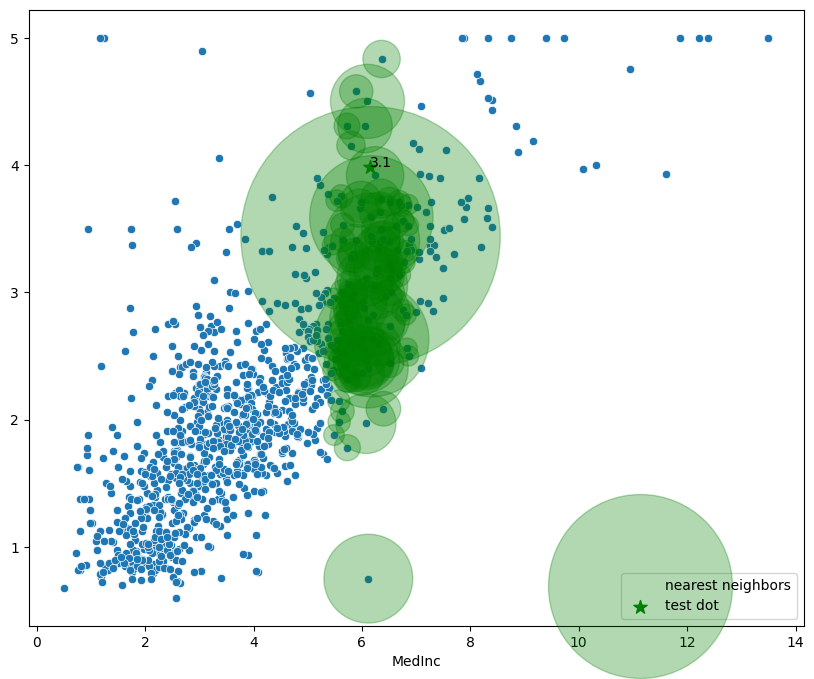

In [66]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=X_train.iloc[:, 0],
    y=y_train
)

plt.scatter(
    X_train.iloc[nearest_neigbors_idxs, 0],
    y_train[nearest_neigbors_idxs],
    c='g',
    alpha=0.3,
    marker='o',
    s=distances['weight'] * 150,
    label='nearest neighbors'
)

plt.scatter(
    X_test.iloc[idx, 0],
    y_test[idx],
    c='g',
    marker='*',
    s=100,
    label='test dot'
)

plt.annotate(round(pred, 1), (X_test.iloc[idx, 0], y_test[idx]))
plt.legend()

## 6. Подберите лучшие гиперпараметры для последней модели, используя класс [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html)

Примеры использования можно найти в технической документации, предыдущей работе, а также в следующих источниках:

[Пример 1](https://machinelearningknowledge.ai/knn-classifier-in-sklearn-using-gridsearchcv-with-example/#vii_Model_fitting_with_K-cross_Validation_and_GridSearchCV)


[Пример 2](https://vc.ru/ml/147132-kak-avtomaticheski-podobrat-parametry-dlya-modeli-mashinnogo-obucheniya-ispolzuem-gridsearchcv)

In [67]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_neighbors': [20, 50, 100, 150],
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(
    KNeighborsRegressor(),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

grid.best_params_, grid.best_score_


({'n_neighbors': 50, 'weights': 'uniform'}, np.float64(0.5804368961487099))